# Laboratorio 06 - Reconstruccion de los 5 laboratorios con PyTorch

**Estudiante:** Arduz Espada Juan Sebastian

**Materia:** SIS 420 - Inteligencia Artificial I

---

### Enunciado

> Utilizando la libreria **PyTorch**, reconstruir todos los modelos de los primeros cinco
> laboratorios, considerando **objetos para manejo de datos (Dataset y DataLoader)**,
> **objetos para optimizacion y costo**, **objetos para guardar los pesos** y otros que
> considere importantes. Se debe considerar la **generacion de metricas**.

### Los cinco modelos a reconstruir

| Lab | Problema original | Dataset | Modelo en PyTorch | Funcion de costo |
|---|---|---|---|---|
| 01 | Regresion lineal simple | Auto MPG | `nn.Linear(1, 1)` | `nn.MSELoss` |
| 02 | Regresion lineal multiple | Buzz in Social Media | `nn.Linear(96, 1)` | `nn.MSELoss` |
| 03 | Multivariable + polinomica + ec. normal | Communities and Crime | `nn.Linear(n, 1)` x2 + `torch.linalg.lstsq` | `nn.MSELoss` |
| 04 | Regresion logistica binaria | Credit Card Default | `nn.Linear(26, 1)` | `nn.BCEWithLogitsLoss` |
| 05 | Clasificacion multiclase one vs. all | Kuzushiji-MNIST | `nn.Linear(784, 10)` | `nn.CrossEntropyLoss` |

En los laboratorios originales **todo estaba escrito a mano**: el gradiente, la funcion de
costo, la sigmoide, el bucle de entrenamiento. Aqui se reconstruye lo mismo delegando cada
pieza al objeto de PyTorch que le corresponde.

### Correspondencia entre lo hecho a mano y los objetos de PyTorch

| Lo que se escribio a mano en los labs 01-05 | Objeto de PyTorch que lo reemplaza |
|---|---|
| Cargar el CSV y cortar en lotes con indices | `Dataset` + `DataLoader` |
| `calcular_costo()` con la formula del error | `nn.MSELoss`, `nn.BCEWithLogitsLoss`, `nn.CrossEntropyLoss` |
| Calcular el gradiente derivando a mano | `loss.backward()` (autograd) |
| `theta = theta - alpha * gradiente` | `torch.optim.SGD`, `torch.optim.Adam` |
| Guardar `theta` en una variable | `torch.save(modelo.state_dict(), ruta)` |
| Contar aciertos con bucles | Funciones de metrica sobre los tensores acumulados |
| El bucle `for i in range(iteraciones)` | Clase `Entrenador` reutilizable |

### Objetos adicionales que se construyen

Ademas de los que pide el enunciado, se definen tres clases propias para no repetir codigo
cinco veces:

- **`DatasetTabular`** - hereda de `torch.utils.data.Dataset`, sirve para los cinco casos.
- **`GestorCheckpoints`** - encapsula el guardado y la recuperacion de pesos, guardando
  siempre el mejor modelo visto hasta el momento.
- **`Entrenador`** - encapsula el bucle de entrenamiento, la evaluacion, el registro del
  historial y la coordinacion con el gestor de checkpoints.

---
## 1. Preparacion del entorno

In [1]:
import os
import time
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print('PyTorch version:', torch.__version__)

dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', dispositivo)

# Semillas fijas para que los resultados sean reproducibles
SEMILLA = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

CARPETA_PESOS = 'pesos'
os.makedirs(CARPETA_PESOS, exist_ok=True)
print('Carpeta para los checkpoints:', CARPETA_PESOS)

PyTorch version: 2.14.0+cpu
Dispositivo: cpu
Carpeta para los checkpoints: pesos


In [2]:
def descargar(url, destino):
    """Descarga un archivo solo si no existe todavia."""
    if not os.path.exists(destino):
        print('Descargando', destino, '...')
        urllib.request.urlretrieve(url, destino)
    return destino


def dividir_80_20(m, semilla=42):
    """Devuelve los indices de entrenamiento y prueba con el mismo criterio
    que se uso en los laboratorios originales."""
    generador = np.random.RandomState(semilla)
    indices = generador.permutation(m)
    corte = int(m * 0.8)
    return indices[:corte], indices[corte:]


def normalizar_con_train(X_train, X_test):
    """z-score calculado SOLO con el conjunto de entrenamiento."""
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma == 0] = 1.0
    return (X_train - mu) / sigma, (X_test - mu) / sigma, mu, sigma


def normalizar_etiqueta(y_train, y_test):
    """Normaliza tambien la etiqueta. Devuelve mu y sigma para poder deshacerlo."""
    mu = y_train.mean()
    sigma = y_train.std()
    if sigma == 0:
        sigma = 1.0
    return (y_train - mu) / sigma, (y_test - mu) / sigma, mu, sigma


print('Utilidades definidas')

Utilidades definidas


> ### Por que hay que normalizar tambien la etiqueta
>
> En los laboratorios 02 y 03 la variable a predecir toma valores enormes: el *buzz* llega
> a **265.916** y la tasa de criminalidad a **4.877**. Para acertar esos valores el modelo
> necesita un sesgo del orden de miles.
>
> El problema es que **Adam limita el tamanio de cada paso a la tasa de aprendizaje**. Con
> `lr = 0.01`, cada parametro se mueve como mucho 0.01 por actualizacion, asi que llegar a
> un sesgo de 3.486 exigiria cientos de miles de pasos. Con 40 epocas de 89 lotes son 3.560
> pasos: el modelo se queda muy lejos y da un R² ridiculo pese a que el problema es facil
> (una sola variable, `ND_7`, ya correlaciona **0.96** con la etiqueta).
>
> La solucion es **normalizar la etiqueta igual que las caracteristicas** y deshacer la
> normalizacion antes de calcular las metricas finales:
>
> `y_real = y_predicho_normalizado * sigma + mu`
>
> Las curvas de R² del historial siguen siendo validas sin conversion, porque **el R² es
> invariante a transformaciones afines**: da el mismo valor en unidades normalizadas que en
> las originales. Solo el MAE y el RMSE necesitan volver a la escala real.

---
## 2. Objetos para el manejo de datos

### `DatasetTabular`

Es la clase que pide el enunciado. Hereda de `torch.utils.data.Dataset` y solo necesita
implementar tres metodos:

- `__init__` guarda los datos convertidos a tensores
- `__len__` devuelve cuantos ejemplos hay
- `__getitem__` devuelve el ejemplo `i`

El `DataLoader` usa esos tres metodos para armar los lotes automaticamente, barajarlos en
cada epoca y entregarlos uno a uno al bucle de entrenamiento. Es lo que en los
laboratorios anteriores se hacia a mano con `np.random.permutation` y rebanadas de arreglo.

El parametro `tipo_etiqueta` permite usar la misma clase para los tres casos: `float` para
regresion, `float` para clasificacion binaria (que `BCEWithLogitsLoss` espera como float) y
`long` para clasificacion multiclase (que `CrossEntropyLoss` espera como entero).

In [3]:
class DatasetTabular(Dataset):
    """Dataset generico para datos en forma de tabla.

    Sirve para los cinco laboratorios cambiando solo el tipo de la etiqueta.
    """

    def __init__(self, X, y, tipo_etiqueta='float'):
        self.X = torch.tensor(np.asarray(X), dtype=torch.float32)

        if tipo_etiqueta == 'long':
            # Clasificacion multiclase: CrossEntropyLoss espera enteros
            self.y = torch.tensor(np.asarray(y), dtype=torch.long)
        else:
            # Regresion y clasificacion binaria: forma (m, 1)
            self.y = torch.tensor(np.asarray(y), dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, indice):
        return self.X[indice], self.y[indice]


# Prueba rapida con datos inventados
prueba = DatasetTabular(np.arange(20).reshape(10, 2), np.arange(10))
print('Ejemplos en el dataset de prueba:', len(prueba))
print('Ejemplo numero 3 ->', prueba[3])

cargador_prueba = DataLoader(prueba, batch_size=4, shuffle=False)
print('Lotes que genera con batch_size=4:', len(cargador_prueba))
for lote_X, lote_y in cargador_prueba:
    print('Forma del primer lote:', lote_X.shape, lote_y.shape)
    break

Ejemplos en el dataset de prueba: 10
Ejemplo numero 3 -> 

(tensor([6., 7.]), tensor([3.]))
Lotes que genera con batch_size=4: 3


Forma del primer lote: torch.Size([4, 2]) torch.Size([4, 1])


---
## 3. Objeto para guardar los pesos

### `GestorCheckpoints`

Encapsula lo que pide el enunciado sobre guardar pesos. Guarda dos cosas distintas:

- **`_mejor.pt`** - se sobrescribe cada vez que el modelo mejora su metrica de validacion.
  Es el que interesa recuperar al final.
- **`_final.pt`** - el estado al terminar todas las epocas, que no siempre es el mejor.

El checkpoint no guarda solo los pesos: guarda tambien el estado del **optimizador**, la
epoca y la metrica. Eso permite reanudar un entrenamiento interrumpido exactamente donde
se quedo, no solo cargar el modelo para inferir.

In [4]:
class GestorCheckpoints:
    """Guarda y recupera los pesos de un modelo."""

    def __init__(self, nombre, carpeta=CARPETA_PESOS, mayor_es_mejor=True):
        self.nombre = nombre
        self.carpeta = carpeta
        self.mayor_es_mejor = mayor_es_mejor
        self.mejor_valor = None
        self.ruta_mejor = os.path.join(carpeta, nombre + '_mejor.pt')
        self.ruta_final = os.path.join(carpeta, nombre + '_final.pt')

    def es_mejora(self, valor):
        if self.mejor_valor is None:
            return True
        if self.mayor_es_mejor:
            return valor > self.mejor_valor
        return valor < self.mejor_valor

    def guardar_si_mejora(self, modelo, optimizador, epoca, valor):
        """Guarda el checkpoint solo si la metrica mejoro."""
        if not self.es_mejora(valor):
            return False

        self.mejor_valor = valor
        torch.save({
            'epoca': epoca,
            'estado_modelo': modelo.state_dict(),
            'estado_optimizador': optimizador.state_dict(),
            'metrica': valor,
        }, self.ruta_mejor)
        return True

    def guardar_final(self, modelo, optimizador, epoca):
        torch.save({
            'epoca': epoca,
            'estado_modelo': modelo.state_dict(),
            'estado_optimizador': optimizador.state_dict(),
        }, self.ruta_final)

    def cargar_mejor(self, modelo):
        """Restaura en el modelo los pesos del mejor checkpoint."""
        checkpoint = torch.load(self.ruta_mejor, map_location=dispositivo)
        modelo.load_state_dict(checkpoint['estado_modelo'])
        return checkpoint


print('GestorCheckpoints definido')

GestorCheckpoints definido


---
## 4. Objeto para el entrenamiento

### `Entrenador`

Reemplaza el bucle `for i in range(iteraciones)` que se escribia a mano en cada
laboratorio. Recibe el modelo, el **objeto de costo** (`criterio`) y el **objeto de
optimizacion** (`optimizador`), y se encarga de:

1. Recorrer las epocas y, dentro de cada una, los lotes que entrega el `DataLoader`.
2. Ejecutar los cinco pasos de PyTorch en cada lote:
   `optimizador.zero_grad()` -> `salida = modelo(x)` -> `perdida = criterio(salida, y)`
   -> `perdida.backward()` -> `optimizador.step()`.
3. Evaluar sobre entrenamiento y prueba al final de cada epoca.
4. Registrar el historial de costo y de metrica.
5. Pedirle al `GestorCheckpoints` que guarde si hubo mejora.

**Por que `zero_grad()`.** PyTorch **acumula** los gradientes en lugar de reemplazarlos. Si
no se limpian al inicio de cada lote, el gradiente del lote actual se sumaria al del
anterior y el entrenamiento se corrompe. Es el error mas comun al empezar con PyTorch.

In [5]:
class Entrenador:
    """Encapsula el bucle de entrenamiento, la evaluacion y los checkpoints."""

    def __init__(self, modelo, criterio, optimizador, metrica_fn,
                 nombre_metrica='metrica', gestor=None, mayor_es_mejor=True):
        self.modelo = modelo.to(dispositivo)
        self.criterio = criterio           # objeto de costo
        self.optimizador = optimizador     # objeto de optimizacion
        self.metrica_fn = metrica_fn
        self.nombre_metrica = nombre_metrica
        self.gestor = gestor
        self.mayor_es_mejor = mayor_es_mejor
        self.historial = {'epoca': [], 'costo_train': [], 'costo_test': [],
                          'metrica_train': [], 'metrica_test': []}

    def _pasada_evaluacion(self, cargador):
        """Recorre un DataLoader sin actualizar pesos. Devuelve costo y metrica."""
        self.modelo.eval()
        suma_costo = 0.0
        total = 0
        salidas = []
        etiquetas = []

        with torch.no_grad():
            for lote_X, lote_y in cargador:
                lote_X = lote_X.to(dispositivo)
                lote_y = lote_y.to(dispositivo)

                salida = self.modelo(lote_X)
                perdida = self.criterio(salida, lote_y)

                suma_costo += perdida.item() * len(lote_X)
                total += len(lote_X)
                salidas.append(salida.cpu())
                etiquetas.append(lote_y.cpu())

        salidas = torch.cat(salidas)
        etiquetas = torch.cat(etiquetas)
        return suma_costo / total, self.metrica_fn(etiquetas, salidas)

    def entrenar(self, cargador_train, cargador_test, epocas, mostrar_cada=1):
        inicio = time.time()

        for epoca in range(1, epocas + 1):
            self.modelo.train()

            for lote_X, lote_y in cargador_train:
                lote_X = lote_X.to(dispositivo)
                lote_y = lote_y.to(dispositivo)

                # --- los cinco pasos de PyTorch ---
                self.optimizador.zero_grad()          # 1. limpiar gradientes
                salida = self.modelo(lote_X)          # 2. paso hacia adelante
                perdida = self.criterio(salida, lote_y)   # 3. calcular el costo
                perdida.backward()                    # 4. calcular gradientes
                self.optimizador.step()               # 5. actualizar pesos

            costo_tr, metrica_tr = self._pasada_evaluacion(cargador_train)
            costo_te, metrica_te = self._pasada_evaluacion(cargador_test)

            self.historial['epoca'].append(epoca)
            self.historial['costo_train'].append(costo_tr)
            self.historial['costo_test'].append(costo_te)
            self.historial['metrica_train'].append(metrica_tr)
            self.historial['metrica_test'].append(metrica_te)

            marca = ''
            if self.gestor is not None:
                if self.gestor.guardar_si_mejora(self.modelo, self.optimizador,
                                                 epoca, metrica_te):
                    marca = '  <- checkpoint guardado'

            if epoca % mostrar_cada == 0 or epoca == 1 or epoca == epocas:
                print('Epoca ' + str(epoca).rjust(3) +
                      '  costo_train=' + format(costo_tr, '.5f') +
                      '  costo_test=' + format(costo_te, '.5f') +
                      '  ' + self.nombre_metrica + '=' + format(metrica_te, '.4f') +
                      marca)

        if self.gestor is not None:
            self.gestor.guardar_final(self.modelo, self.optimizador, epocas)

        print('Tiempo de entrenamiento: %.1f s' % (time.time() - inicio))
        return self.historial


print('Entrenador definido')

Entrenador definido


---
## 5. Funciones de metrica

El enunciado pide **generacion de metricas**. Se definen las tres familias que hacen falta:
regresion, clasificacion binaria y clasificacion multiclase.

In [6]:
# np.trapezoid existe desde NumPy 2.0; en versiones anteriores se llama np.trapz
_integrar = getattr(np, 'trapezoid', None)
if _integrar is None:
    _integrar = np.trapz


def metrica_r2(y_real, y_pred):
    """Coeficiente de determinacion R2: que porcentaje de la varianza explica el modelo."""
    y_real = y_real.view(-1).numpy()
    y_pred = y_pred.view(-1).numpy()
    ss_residual = np.sum((y_real - y_pred) ** 2)
    ss_total = np.sum((y_real - y_real.mean()) ** 2)
    return float(1 - ss_residual / ss_total)


def metricas_regresion(y_real, y_pred):
    y_real = y_real.view(-1).numpy()
    y_pred = y_pred.view(-1).numpy()
    error = y_pred - y_real
    ss_residual = np.sum(error ** 2)
    ss_total = np.sum((y_real - y_real.mean()) ** 2)
    return {
        'MAE': float(np.mean(np.abs(error))),
        'RMSE': float(np.sqrt(np.mean(error ** 2))),
        'R2': float(1 - ss_residual / ss_total),
    }


def metrica_exactitud_binaria(y_real, salida_cruda):
    """El modelo devuelve logits; el umbral 0 en logit equivale a 0.5 en probabilidad."""
    predicho = (salida_cruda.view(-1) >= 0).float()
    return float((predicho == y_real.view(-1)).float().mean())


def metricas_binarias(y_real, salida_cruda, umbral_prob=0.5):
    probabilidad = torch.sigmoid(salida_cruda.view(-1)).numpy()
    real = y_real.view(-1).numpy()
    predicho = (probabilidad >= umbral_prob).astype(float)

    vp = float(np.sum((predicho == 1) & (real == 1)))
    vn = float(np.sum((predicho == 0) & (real == 0)))
    fp = float(np.sum((predicho == 1) & (real == 0)))
    fn = float(np.sum((predicho == 0) & (real == 1)))

    precision = vp / (vp + fp) if vp + fp > 0 else 0.0
    sensibilidad = vp / (vp + fn) if vp + fn > 0 else 0.0
    f1 = (2 * precision * sensibilidad / (precision + sensibilidad)
          if precision + sensibilidad > 0 else 0.0)

    orden = np.argsort(-probabilidad)
    real_ordenado = real[orden]
    tpr = np.concatenate([[0], np.cumsum(real_ordenado) / real_ordenado.sum()])
    fpr = np.concatenate([[0], np.cumsum(1 - real_ordenado) / (1 - real_ordenado).sum()])

    return {'VP': int(vp), 'VN': int(vn), 'FP': int(fp), 'FN': int(fn),
            'exactitud': (vp + vn) / len(real),
            'precision': precision, 'sensibilidad': sensibilidad, 'F1': f1,
            'AUC': float(_integrar(tpr, fpr))}


def metrica_exactitud_multiclase(y_real, salida_cruda):
    predicho = torch.argmax(salida_cruda, dim=1)
    return float((predicho == y_real).float().mean())


def metricas_multiclase(y_real, salida_cruda, num_clases):
    predicho = torch.argmax(salida_cruda, dim=1).numpy()
    real = y_real.numpy()

    matriz = np.zeros((num_clases, num_clases), dtype=int)
    for a, b in zip(real, predicho):
        matriz[a, b] += 1

    f1_por_clase = []
    for k in range(num_clases):
        vp = matriz[k, k]
        pr = vp / matriz[:, k].sum() if matriz[:, k].sum() else 0.0
        rc = vp / matriz[k, :].sum() if matriz[k, :].sum() else 0.0
        f1_por_clase.append(2 * pr * rc / (pr + rc) if pr + rc else 0.0)

    return {'exactitud': float((predicho == real).mean()),
            'F1_macro': float(np.mean(f1_por_clase)),
            'matriz': matriz,
            'F1_por_clase': f1_por_clase}


print('Funciones de metrica definidas')

Funciones de metrica definidas


In [7]:
def graficar_historial(historial, titulo, nombre_metrica, ax_costo=None, ax_metrica=None):
    """Dibuja la curva de costo y la de metrica de un entrenamiento."""
    creado_aqui = ax_costo is None
    if creado_aqui:
        fig, (ax_costo, ax_metrica) = plt.subplots(1, 2, figsize=(13, 4))

    epocas = historial['epoca']
    ax_costo.plot(epocas, historial['costo_train'], color='#4c72b0',
                  linewidth=2, label='Entrenamiento')
    ax_costo.plot(epocas, historial['costo_test'], color='#dd8452',
                  linewidth=2, linestyle='--', label='Prueba')
    ax_costo.set_title(titulo + ' - Costo', fontsize=12)
    ax_costo.set_xlabel('Epoca'); ax_costo.set_ylabel('Costo')
    ax_costo.legend(); ax_costo.grid(True, alpha=0.3)

    ax_metrica.plot(epocas, historial['metrica_train'], color='#4c72b0',
                    linewidth=2, label='Entrenamiento')
    ax_metrica.plot(epocas, historial['metrica_test'], color='#dd8452',
                    linewidth=2, linestyle='--', label='Prueba')
    ax_metrica.set_title(titulo + ' - ' + nombre_metrica, fontsize=12)
    ax_metrica.set_xlabel('Epoca'); ax_metrica.set_ylabel(nombre_metrica)
    ax_metrica.legend(); ax_metrica.grid(True, alpha=0.3)

    if creado_aqui:
        plt.tight_layout()
        plt.show()


resultados = {}   # aca se van guardando los resultados de los 5 modelos
print('Listo para entrenar')

Listo para entrenar


---
# MODELO 1 - Laboratorio 01

## Regresion lineal simple con `nn.Linear(1, 1)`

**Dataset:** Auto MPG. `x` = peso del vehiculo, `y` = consumo en millas por galon.

En el laboratorio original los parametros se encontraron con una **busqueda por rejilla**,
probando miles de combinaciones de `b` y `w` sin usar derivadas. El resultado fue
`b = 46.317364` y `w = -0.00767661`.

Aqui se resuelve con `nn.Linear(1, 1)`, que tiene exactamente esos dos parametros: `weight`
es `w` y `bias` es `b`. La diferencia es que ahora los encuentra el **gradiente
descendente** por medio de autograd.

**Detalle importante.** El peso del vehiculo va de 1613 a 5140. Entrenar directamente sobre
esos valores obligaria a una tasa de aprendizaje minuscula. Por eso se normaliza `x`, y al
final se **deshace la normalizacion** para recuperar `b` y `w` en las unidades originales y
poder compararlos con el laboratorio 01:

Si `x' = (x - mu) / sigma` y el modelo aprende `y = b' + w' x'`, entonces:

$$ w = \frac{w'}{\sigma} \qquad\qquad b = b' - \frac{w' \mu}{\sigma} $$

In [8]:
URL_MPG = 'https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv'
descargar(URL_MPG, 'auto-mpg.csv')

mpg = pd.read_csv('auto-mpg.csv')
mpg = mpg[['weight', 'mpg']].dropna()

X1 = mpg[['weight']].values.astype(np.float64)
y1 = mpg['mpg'].values.astype(np.float64)

print('m =', len(y1), ' n =', X1.shape[1])

idx_tr1, idx_te1 = dividir_80_20(len(y1))
X1_tr, X1_te = X1[idx_tr1], X1[idx_te1]
y1_tr, y1_te = y1[idx_tr1], y1[idx_te1]

X1_tr_n, X1_te_n, mu1, sigma1 = normalizar_con_train(X1_tr, X1_te)

ds1_tr = DatasetTabular(X1_tr_n, y1_tr)
ds1_te = DatasetTabular(X1_te_n, y1_te)

carg1_tr = DataLoader(ds1_tr, batch_size=32, shuffle=True)
carg1_te = DataLoader(ds1_te, batch_size=32, shuffle=False)

print('Entrenamiento:', len(ds1_tr), ' Prueba:', len(ds1_te))
print('Lotes por epoca:', len(carg1_tr))

m = 398  n = 1
Entrenamiento: 318  Prueba: 80
Lotes por epoca: 10


In [9]:
torch.manual_seed(SEMILLA)

modelo1 = nn.Linear(1, 1)                                   # el modelo
criterio1 = nn.MSELoss()                                    # objeto de costo
optimizador1 = torch.optim.SGD(modelo1.parameters(), lr=0.05)   # objeto de optimizacion
gestor1 = GestorCheckpoints('lab01_lineal_simple', mayor_es_mejor=True)

print('Modelo:', modelo1)
print('Parametros entrenables:', sum(p.numel() for p in modelo1.parameters()))
print('Costo:', criterio1)
print('Optimizador:', type(optimizador1).__name__)

entrenador1 = Entrenador(modelo1, criterio1, optimizador1,
                         metrica_r2, 'R2', gestor1)
hist1 = entrenador1.entrenar(carg1_tr, carg1_te, epocas=60, mostrar_cada=10)

Modelo: Linear(in_features=1, out_features=1, bias=True)
Parametros entrenables: 2
Costo: MSELoss()
Optimizador: SGD


Epoca   1  costo_train=88.55873  costo_test=88.76222  R2=-0.5105  <- checkpoint guardado
Epoca  10  costo_train=18.83996  costo_test=18.62029  R2=0.6831
Epoca  20  costo_train=18.84953  costo_test=18.67265  R2=0.6822


Epoca  30  costo_train=18.83904  costo_test=18.56908  R2=0.6840
Epoca  40  costo_train=18.83954  costo_test=18.58899  R2=0.6837
Epoca  50  costo_train=18.84560  costo_test=18.62228  R2=0.6831


Epoca  60  costo_train=18.83821  costo_test=18.61685  R2=0.6832
Tiempo de entrenamiento: 1.4 s


In [10]:
gestor1.cargar_mejor(modelo1)

# Deshacer la normalizacion para recuperar b y w en unidades originales
w_norm = float(modelo1.weight.detach().cpu().item())
b_norm = float(modelo1.bias.detach().cpu().item())

w_real = w_norm / float(sigma1[0])
b_real = b_norm - w_norm * float(mu1[0]) / float(sigma1[0])

print('Parametros aprendidos por PyTorch (en escala original):')
print('  b =', round(b_real, 6))
print('  w =', round(w_real, 8))
print()
print('Parametros del Laboratorio 01 (busqueda por rejilla en Python puro):')
print('  b = 46.317364')
print('  w = -0.00767661')
print()
print('Diferencia en b:', round(abs(b_real - 46.317364), 6))
print('Diferencia en w:', round(abs(w_real - (-0.00767661)), 10))

modelo1.eval()
with torch.no_grad():
    pred1 = modelo1(ds1_te.X.to(dispositivo)).cpu()
met1 = metricas_regresion(ds1_te.y, pred1)
print()
print('Metricas sobre el conjunto de prueba:', {k: round(v, 4) for k, v in met1.items()})
resultados['Lab 01 - Lineal simple'] = met1

Parametros aprendidos por PyTorch (en escala original):
  b = 46.336226
  w = -0.00767056

Parametros del Laboratorio 01 (busqueda por rejilla en Python puro):
  b = 46.317364
  w = -0.00767661

Diferencia en b: 0.018862
Diferencia en w: 6.0524e-06

Metricas sobre el conjunto de prueba: {'MAE': 3.3879, 'RMSE': 4.307, 'R2': 0.6843}


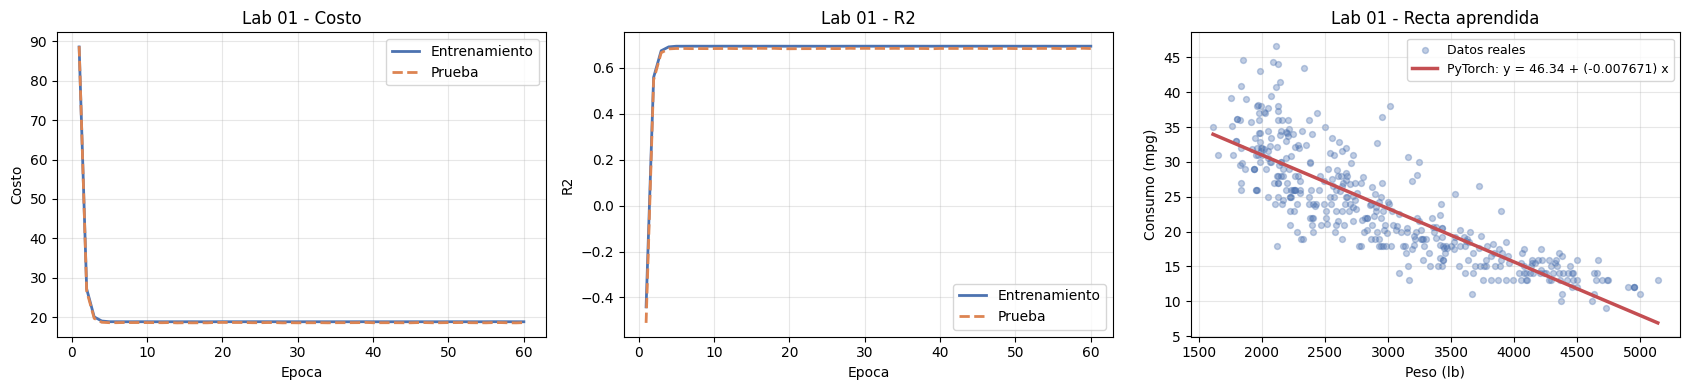

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4))
graficar_historial(hist1, 'Lab 01', 'R2', ax1, ax2)

# La recta aprendida sobre los datos reales
orden = np.argsort(X1[:, 0])
x_linea = np.array([X1[:, 0].min(), X1[:, 0].max()])
y_linea = b_real + w_real * x_linea

ax3.scatter(X1[:, 0], y1, alpha=0.35, s=18, color='#4c72b0', label='Datos reales')
ax3.plot(x_linea, y_linea, color='#c44e52', linewidth=2.5,
         label='PyTorch: y = ' + str(round(b_real, 2)) + ' + (' +
               str(round(w_real, 6)) + ') x')
ax3.set_title('Lab 01 - Recta aprendida', fontsize=12)
ax3.set_xlabel('Peso (lb)'); ax3.set_ylabel('Consumo (mpg)')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# MODELO 2 - Laboratorio 02

## Regresion lineal multiple con `nn.Linear(96, 1)`

**Dataset:** Buzz in Social Media (TomsHardware), 28.179 ejemplos y 96 caracteristicas.

Es el mismo problema del laboratorio 02, donde el gradiente descendente se implemento a
mano con `alpha = 0.01` y 10.000 iteraciones sobre todo el dataset de golpe.

Aqui se usa **entrenamiento por lotes** (`batch_size = 256`) con el optimizador **Adam**,
que adapta la tasa de aprendizaje de cada parametro por separado. Con lotes, cada epoca
hace 89 actualizaciones de pesos en lugar de una sola, asi que hacen falta muchisimas menos
epocas.

In [12]:
URL_BUZZ = ('https://raw.githubusercontent.com/Sebillasxd2/SIS-420---IA/'
            'main/TomsHardware.data')
descargar(URL_BUZZ, 'TomsHardware.data')

nombres = []
for categoria in ['NCD', 'BL', 'NAD', 'AI', 'NAC', 'ND', 'CS', 'AT',
                  'NA', 'ADL', 'AS_NA', 'AS_NAC']:
    for t in range(8):
        nombres.append(categoria + '_' + str(t))
nombres.append('target_buzz')

buzz = pd.read_csv('TomsHardware.data', header=None, names=nombres)
print('Dataset Buzz:', buzz.shape)

X2 = buzz.drop(columns=['target_buzz']).values.astype(np.float64)
y2 = buzz['target_buzz'].values.astype(np.float64)
print('m =', X2.shape[0], ' n =', X2.shape[1])

idx_tr2, idx_te2 = dividir_80_20(len(y2))
X2_tr_n, X2_te_n, mu2, sigma2 = normalizar_con_train(X2[idx_tr2], X2[idx_te2])
y2_tr, y2_te = y2[idx_tr2], y2[idx_te2]

# La etiqueta llega a 265.916, hay que normalizarla para que Adam pueda alcanzarla
y2_tr_n, y2_te_n, mu_y2, sigma_y2 = normalizar_etiqueta(y2_tr, y2_te)
print('Etiqueta: media =', round(mu_y2, 2), ' desviacion =', round(sigma_y2, 2))

ds2_tr = DatasetTabular(X2_tr_n, y2_tr_n)
ds2_te = DatasetTabular(X2_te_n, y2_te_n)
carg2_tr = DataLoader(ds2_tr, batch_size=256, shuffle=True)
carg2_te = DataLoader(ds2_te, batch_size=256, shuffle=False)

print('Entrenamiento:', len(ds2_tr), ' Prueba:', len(ds2_te))
print('Lotes por epoca:', len(carg2_tr))

Dataset Buzz: (28179, 97)
m = 28179  n = 96
Etiqueta: media = 3499.93  desviacion = 13050.22
Entrenamiento: 22543  Prueba: 5636
Lotes por epoca: 89


In [13]:
torch.manual_seed(SEMILLA)

modelo2 = nn.Linear(X2.shape[1], 1)
criterio2 = nn.MSELoss()
optimizador2 = torch.optim.Adam(modelo2.parameters(), lr=0.01)
gestor2 = GestorCheckpoints('lab02_lineal_multiple', mayor_es_mejor=True)

print('Parametros entrenables:', sum(p.numel() for p in modelo2.parameters()),
      '(96 pesos + 1 sesgo)')

entrenador2 = Entrenador(modelo2, criterio2, optimizador2, metrica_r2, 'R2', gestor2)
hist2 = entrenador2.entrenar(carg2_tr, carg2_te, epocas=40, mostrar_cada=5)

Parametros entrenables: 97 (96 pesos + 1 sesgo)


Epoca   1  costo_train=0.08810  costo_test=0.08213  R2=0.9064  <- checkpoint guardado


Epoca   5  costo_train=0.05535  costo_test=0.05249  R2=0.9402


Epoca  10  costo_train=0.14099  costo_test=0.12286  R2=0.8600


Epoca  15  costo_train=0.04110  costo_test=0.04025  R2=0.9541


Epoca  20  costo_train=0.04583  costo_test=0.04505  R2=0.9487


Epoca  25  costo_train=0.04641  costo_test=0.04764  R2=0.9457


Epoca  30  costo_train=0.03760  costo_test=0.03761  R2=0.9572


Epoca  35  costo_train=0.04601  costo_test=0.04493  R2=0.9488


Epoca  40  costo_train=0.08217  costo_test=0.07608  R2=0.9133
Tiempo de entrenamiento: 12.6 s


Metricas sobre el conjunto de prueba (en unidades de buzz): {'MAE': 665.7007, 'RMSE': 2507.3081, 'R2': 0.9579}


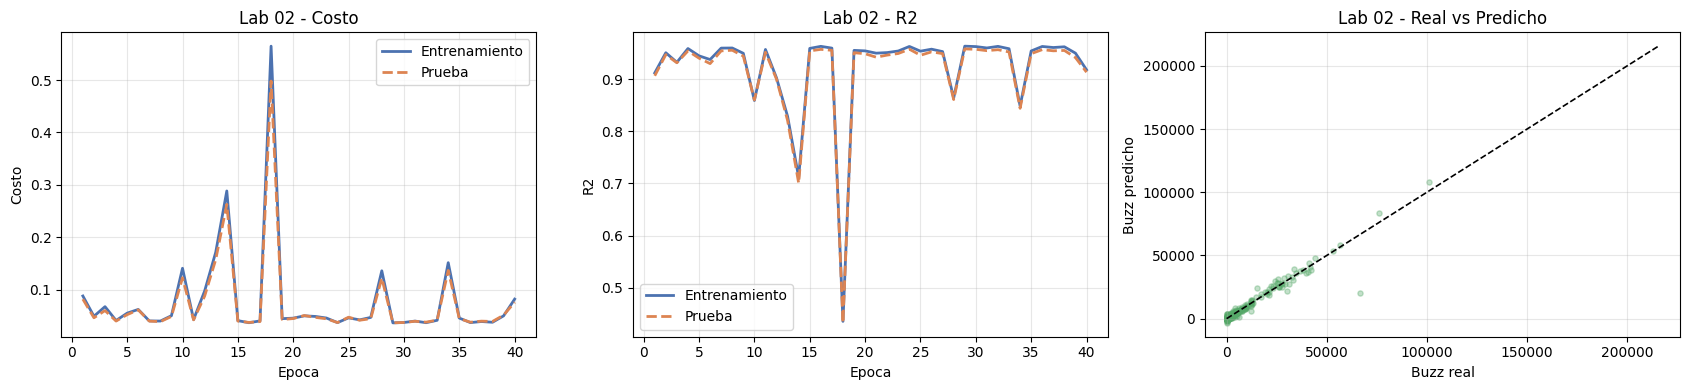

In [14]:
gestor2.cargar_mejor(modelo2)
modelo2.eval()
with torch.no_grad():
    pred2_norm = modelo2(ds2_te.X.to(dispositivo)).cpu()

# Deshacer la normalizacion para que las metricas esten en unidades de buzz
pred2 = pred2_norm * sigma_y2 + mu_y2
y2_te_tensor = torch.tensor(y2_te, dtype=torch.float32).view(-1, 1)

met2 = metricas_regresion(y2_te_tensor, pred2)
print('Metricas sobre el conjunto de prueba (en unidades de buzz):',
      {k: round(v, 4) for k, v in met2.items()})
resultados['Lab 02 - Lineal multiple'] = met2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4))
graficar_historial(hist2, 'Lab 02', 'R2', ax1, ax2)

real2 = y2_te_tensor.view(-1).numpy()
estimado2 = pred2.view(-1).numpy()
muestra2 = np.random.RandomState(0).choice(len(real2), 800, replace=False)
ax3.scatter(real2[muestra2], estimado2[muestra2], alpha=0.35, s=14, color='#55a868')
limite = max(real2.max(), estimado2.max())
ax3.plot([0, limite], [0, limite], 'k--', linewidth=1.2)
ax3.set_title('Lab 02 - Real vs Predicho', fontsize=12)
ax3.set_xlabel('Buzz real'); ax3.set_ylabel('Buzz predicho')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# MODELO 3 - Laboratorio 03

## Multivariable, polinomica y ecuacion normal

**Dataset:** Communities and Crime Unnormalized (UCI). Se predice la tasa de crimenes
violentos por cada 100.000 habitantes.

El laboratorio 03 comparaba **tres modelos**, asi que aqui se reconstruyen los tres:

| Modelo | En PyTorch |
|---|---|
| 3a. Lineal multivariable | `nn.Linear(n, 1)` entrenado con Adam |
| 3b. Polinomica de grado 2 | `nn.Linear(2n, 1)` sobre `[X, X^2]` |
| 3c. Ecuacion normal | `torch.linalg.lstsq`, solucion cerrada sin iterar |

La ecuacion normal es interesante porque **no se entrena**: PyTorch la resuelve de un solo
paso. Se usa `lstsq` en lugar de invertir la matriz a mano porque es numericamente mucho
mas estable cuando las columnas estan correlacionadas, que es justo lo que pasa en este
dataset.

> ### Correccion de un error detectado en el laboratorio 03 original
>
> Al reconstruir este modelo aparecio un resultado imposible: **R² = 0.98** prediciendo
> criminalidad a partir de datos socioeconomicos, con un error absoluto medio de apenas
> 5.3. Ningun modelo lineal logra eso con este problema, asi que habia algo mal.
>
> **El diagnostico.** El archivo `CommViolPredUnnormalizedData.txt` tiene **147 columnas**,
> pero la lista de nombres que se uso en el laboratorio 03 solo tenia **145**. Cuando la
> lista `names` es mas corta que los datos, Pandas no falla: convierte las columnas
> sobrantes del principio en indice y **desplaza todos los nombres dos posiciones**. La
> columna etiquetada `ViolentCrimesPerPop` contenia en realidad otra variable.
>
> Se detectaron **dos errores** en la lista de nombres:
>
> 1. Faltaban `OwnOccQrange` (despues de `OwnOccHiQuart`) y `RentQrange` (despues de
>    `RentHighQ`).
> 2. `ViolentCrimesPerPop` estaba colocada **antes** de `murders`, cuando en el dataset
>    oficial de UCI va **al final**, despues de `arsonsPerPop` y antes de `nonViolPerPop`.
>
> **Como se confirma la correccion.** Con los nombres arreglados la etiqueta pasa a tener
> media 589 y mediana 374 por cada 100.000 habitantes, que es una tasa de criminalidad
> plausible. Antes tenia mediana 1 y maximo 1946, que no lo es. Y las correlaciones pasan
> a ser las conocidas de este dataset:
>
> | Variable | Correlacion con el target |
> |---|---|
> | `PctIlleg` | 0.739 |
> | `PctKids2Par` | 0.729 |
> | `PctFam2Par` | 0.699 |
> | `racePctWhite` | 0.678 |
>
> Antes de la correccion las correlaciones mas altas eran `PctWorkMomYoungKids` (0.978) y
> `OtherPerCap` (0.976), valores absurdos que delataban el desplazamiento.
>
> **Consecuencia.** El numero de ejemplos baja de 2214 a **1994**, porque la etiqueta real
> falta en 221 comunidades. Los resultados de este modelo 3 **no son comparables** con los
> del laboratorio 03 original: aquellos se calcularon sobre una columna equivocada.

In [15]:
URL_CRIMEN = ('https://raw.githubusercontent.com/Sebillasxd2/SIS-420---IA/'
              'main/CommViolPredUnnormalizedData.txt')
descargar(URL_CRIMEN, 'CommViolPredUnnormalizedData.txt')

cols3 = ['communityname','state','countyCode','communityCode','fold',
'population','householdsize','racepctblack','racePctWhite','racePctAsian','racePctHisp',
'agePct12t21','agePct12t29','agePct16t24','agePct65up','numbUrban','pctUrban',
'medIncome','pctWWage','pctWFarmSelf','pctWInvInc','pctWSocSec','pctWPubAsst','pctWRetire',
'medFamInc','perCapInc','whitePerCap','blackPerCap','indianPerCap','AsianPerCap',
'OtherPerCap','HispPerCap','NumUnderPov','PctPopUnderPov','PctLess9thGrade',
'PctNotHSGrad','PctBSorMore','PctUnemployed','PctEmploy','PctEmplManu','PctEmplProfServ',
'PctOccupManu','PctOccupMgmtProf','MalePctDivorce','MalePctNevMarr','FemalePctDiv',
'TotalPctDiv','PersPerFam','PctFam2Par','PctKids2Par','PctYoungKids2Par','PctTeen2Par',
'PctWorkMomYoungKids','PctWorkMom','NumIlleg','PctIlleg','NumImmig','PctImmigRecent',
'PctImmigRec5','PctImmigRec8','PctImmigRec10','PctRecentImmig','PctRecImmig5',
'PctRecImmig8','PctRecImmig10','PctSpeakEnglOnly','PctNotSpeakEnglWell',
'PctLargHouseFam','PctLargHouseOccup','PersPerOccupHous','PersPerOwnOccHous',
'PersPerRentOccHous','PctPersOwnOccup','PctPersDenseHous','PctHousLess3BR','MedNumBR',
'HousVacant','PctHousOccup','PctHousOwnOcc','PctVacantBoarded','PctVacMore6Mos',
'MedYrHousBuilt','PctHousNoPhone','PctWOFullPlumb','OwnOccLowQuart','OwnOccMedVal',
'OwnOccHiQuart','OwnOccQrange','RentLowQ','RentMedian','RentHighQ','RentQrange',
'MedRent','MedRentPctHousInc',
'MedOwnCostPctInc','MedOwnCostPctIncNoMtg','NumInShelters','NumStreet',
'PctForeignBorn','PctBornSameState','PctSameHouse85','PctSameCity85','PctSameState85',
'LemasSwornFT','LemasSwFTPerPop','LemasSwFTFieldOps','LemasSwFTFieldPerPop',
'LemasTotalReq','LemasTotReqPerPop','PolicReqPerOffic','PolicPerPop',
'RacialMatchCommPol','PctPolicWhite','PctPolicBlack','PctPolicHisp','PctPolicAsian',
'PctPolicMinor','OfficAssgnDrugUnits','NumKindsDrugsSeiz','PolicAveOTWorked',
'LandArea','PopDens','PctUsePubTrans','PolicCars','PolicOperBudg',
'LemasPctPolicOnPatr','LemasGangUnitDeploy','LemasPctOfficDrugUn','PolicBudgPerPop',
'murders','murdPerPop','rapes','rapesPerPop',
'robberies','robbbPerPop','assaults','assaultPerPop','burglaries','burglPerPop',
'larcenies','larcPerPop','autoTheft','autoTheftPerPop','arsons','arsonsPerPop',
'ViolentCrimesPerPop','nonViolPerPop']

crimen = pd.read_csv('CommViolPredUnnormalizedData.txt', header=None,
                     names=cols3, na_values='?')

crimen = crimen.drop(columns=['communityname','state','countyCode','communityCode','fold'])
otros_objetivos = ['murders','murdPerPop','rapes','rapesPerPop','robberies','robbbPerPop',
                   'assaults','assaultPerPop','burglaries','burglPerPop','larcenies',
                   'larcPerPop','autoTheft','autoTheftPerPop','arsons','arsonsPerPop',
                   'nonViolPerPop']
crimen = crimen.drop(columns=otros_objetivos)

# Solo sirven las filas que tienen la etiqueta: falta en 221 comunidades
crimen = crimen.dropna(subset=['ViolentCrimesPerPop'])

umbral = len(crimen) * 0.3
crimen = crimen.dropna(thresh=len(crimen) - int(umbral), axis=1).dropna()

X3 = crimen.drop(columns=['ViolentCrimesPerPop']).values.astype(np.float64)
y3 = crimen['ViolentCrimesPerPop'].values.astype(np.float64)
print('Dataset limpio: m =', X3.shape[0], ' n =', X3.shape[1])

idx_tr3, idx_te3 = dividir_80_20(len(y3))
X3_tr, X3_te = X3[idx_tr3], X3[idx_te3]
y3_tr, y3_te = y3[idx_tr3], y3[idx_te3]
X3_tr_n, X3_te_n, mu3, sigma3 = normalizar_con_train(X3_tr, X3_te)
y3_tr_n, y3_te_n, mu_y3, sigma_y3 = normalizar_etiqueta(y3_tr, y3_te)
y3_te_tensor = torch.tensor(y3_te, dtype=torch.float32).view(-1, 1)
print('Etiqueta: media =', round(mu_y3, 2), ' desviacion =', round(sigma_y3, 2))

ds3_tr = DatasetTabular(X3_tr_n, y3_tr_n)
ds3_te = DatasetTabular(X3_te_n, y3_te_n)
carg3_tr = DataLoader(ds3_tr, batch_size=64, shuffle=True)
carg3_te = DataLoader(ds3_te, batch_size=64, shuffle=False)
print('Entrenamiento:', len(ds3_tr), ' Prueba:', len(ds3_te))

Dataset limpio: m = 1993  n = 102
Etiqueta: media = 590.73  desviacion = 615.09
Entrenamiento: 1594  Prueba: 399


### 3a. Regresion lineal multivariable

In [16]:
torch.manual_seed(SEMILLA)

modelo3a = nn.Linear(X3.shape[1], 1)
criterio3a = nn.MSELoss()
optimizador3a = torch.optim.Adam(modelo3a.parameters(), lr=0.05)
gestor3a = GestorCheckpoints('lab03a_lineal', mayor_es_mejor=True)

entrenador3a = Entrenador(modelo3a, criterio3a, optimizador3a, metrica_r2, 'R2', gestor3a)
hist3a = entrenador3a.entrenar(carg3_tr, carg3_te, epocas=150, mostrar_cada=25)

gestor3a.cargar_mejor(modelo3a)
modelo3a.eval()
with torch.no_grad():
    pred3a = modelo3a(ds3_te.X.to(dispositivo)).cpu() * sigma_y3 + mu_y3
met3a = metricas_regresion(y3_te_tensor, pred3a)
print('Metricas:', {k: round(v, 4) for k, v in met3a.items()})
resultados['Lab 03a - Lineal'] = met3a

Epoca   1  costo_train=1.31878  costo_test=0.77897  R2=0.2170  <- checkpoint guardado


Epoca  25  costo_train=0.48285  costo_test=0.44133  R2=0.5564


Epoca  50  costo_train=0.39938  costo_test=0.38036  R2=0.6177


Epoca  75  costo_train=0.51737  costo_test=0.44499  R2=0.5527


Epoca 100  costo_train=0.50811  costo_test=0.43695  R2=0.5608


Epoca 125  costo_train=4.19480  costo_test=1.43274  R2=-0.4401


Epoca 150  costo_train=0.45479  costo_test=0.42667  R2=0.5711
Tiempo de entrenamiento: 5.2 s
Metricas: {'MAE': 249.8318, 'RMSE': 349.5992, 'R2': 0.6753}


### 3b. Regresion polinomica de grado 2

Igual que en el laboratorio 03: se toman las **20 caracteristicas mas correlacionadas** con
la etiqueta y se agregan sus cuadrados, formando 40 caracteristicas. La correlacion se
calcula **solo con el conjunto de entrenamiento** para no filtrar informacion del conjunto
de prueba.

In [17]:
# Correlacion calculada solo con entrenamiento
df3_tr = pd.DataFrame(X3_tr, columns=crimen.drop(columns=['ViolentCrimesPerPop']).columns)
df3_tr['objetivo'] = y3_tr
correlacion = df3_tr.corr()['objetivo'].drop('objetivo').abs().sort_values(ascending=False)
top20 = correlacion.head(20).index.tolist()
indices_top = [list(df3_tr.columns).index(c) for c in top20]

print('Top 5 caracteristicas por correlacion:')
for c in top20[:5]:
    print('  ', c, '->', round(correlacion[c], 4))

X3p_tr = np.concatenate([X3_tr[:, indices_top], X3_tr[:, indices_top] ** 2], axis=1)
X3p_te = np.concatenate([X3_te[:, indices_top], X3_te[:, indices_top] ** 2], axis=1)
X3p_tr_n, X3p_te_n, _, _ = normalizar_con_train(X3p_tr, X3p_te)
print('Caracteristicas polinomicas:', X3p_tr.shape[1], '(20 originales + 20 al cuadrado)')

ds3p_tr = DatasetTabular(X3p_tr_n, y3_tr_n)
ds3p_te = DatasetTabular(X3p_te_n, y3_te_n)
carg3p_tr = DataLoader(ds3p_tr, batch_size=64, shuffle=True)
carg3p_te = DataLoader(ds3p_te, batch_size=64, shuffle=False)

torch.manual_seed(SEMILLA)
modelo3b = nn.Linear(X3p_tr.shape[1], 1)
criterio3b = nn.MSELoss()
optimizador3b = torch.optim.Adam(modelo3b.parameters(), lr=0.05)
gestor3b = GestorCheckpoints('lab03b_polinomica', mayor_es_mejor=True)

entrenador3b = Entrenador(modelo3b, criterio3b, optimizador3b, metrica_r2, 'R2', gestor3b)
hist3b = entrenador3b.entrenar(carg3p_tr, carg3p_te, epocas=150, mostrar_cada=25)

gestor3b.cargar_mejor(modelo3b)
modelo3b.eval()
with torch.no_grad():
    pred3b = modelo3b(ds3p_te.X.to(dispositivo)).cpu() * sigma_y3 + mu_y3
met3b = metricas_regresion(y3_te_tensor, pred3b)
print('Metricas:', {k: round(v, 4) for k, v in met3b.items()})
resultados['Lab 03b - Polinomica'] = met3b

Top 5 caracteristicas por correlacion:
   PctIlleg -> 0.7301
   PctKids2Par -> 0.7221
   PctFam2Par -> 0.6914
   racePctWhite -> 0.673
   PctTeen2Par -> 0.651
Caracteristicas polinomicas: 40 (20 originales + 20 al cuadrado)
Epoca   1  costo_train=0.56663  costo_test=0.56009  R2=0.4370  <- checkpoint guardado


Epoca  25  costo_train=0.41946  costo_test=0.36957  R2=0.6285


Epoca  50  costo_train=0.39069  costo_test=0.36190  R2=0.6362


Epoca  75  costo_train=0.40337  costo_test=0.40248  R2=0.5955


Epoca 100  costo_train=0.39382  costo_test=0.35437  R2=0.6438


Epoca 125  costo_train=0.45443  costo_test=0.42570  R2=0.5721


Epoca 150  costo_train=0.42294  costo_test=0.37134  R2=0.6268
Tiempo de entrenamiento: 5.4 s
Metricas: {'MAE': 239.0326, 'RMSE': 343.7304, 'R2': 0.6861}


### 3c. Ecuacion normal con `torch.linalg.lstsq`

Solucion cerrada: no hay epocas, ni tasa de aprendizaje, ni `DataLoader`. Se resuelve el
sistema de una sola vez.

Se usa `lstsq` en lugar de la formula `(X^T X)^-1 X^T y` porque esta ultima falla o da
resultados sin sentido cuando la matriz esta mal condicionada, que es el caso aqui: muchas
columnas del dataset estan fuertemente correlacionadas entre si.

In [18]:
X3_tr_bias = torch.tensor(np.hstack([np.ones((len(X3_tr), 1)), X3_tr]),
                          dtype=torch.float64)
y3_tr_t = torch.tensor(y3_tr, dtype=torch.float64).view(-1, 1)
X3_te_bias = torch.tensor(np.hstack([np.ones((len(X3_te), 1)), X3_te]),
                          dtype=torch.float64)

inicio = time.time()
solucion = torch.linalg.lstsq(X3_tr_bias, y3_tr_t)
theta_normal = solucion.solution
print('Resuelto en %.4f segundos, sin ninguna iteracion' % (time.time() - inicio))
print('Parametros obtenidos:', theta_normal.shape[0])

# La ecuacion normal se resuelve sobre los valores originales, sin normalizar:
# al ser una solucion cerrada no tiene el problema de escala del gradiente descendente
pred3c = (X3_te_bias @ theta_normal).float()
met3c = metricas_regresion(y3_te_tensor, pred3c)
print('Metricas:', {k: round(v, 4) for k, v in met3c.items()})
resultados['Lab 03c - Ecuacion normal'] = met3c

# Los pesos tambien se guardan, aunque no vengan de un nn.Module
torch.save({'theta': theta_normal},
           os.path.join(CARPETA_PESOS, 'lab03c_ecuacion_normal.pt'))
print('Pesos guardados en', os.path.join(CARPETA_PESOS, 'lab03c_ecuacion_normal.pt'))

Resuelto en 0.6574 segundos, sin ninguna iteracion
Parametros obtenidos: 103
Metricas: {'MAE': 235.7205, 'RMSE': 346.5376, 'R2': 0.681}
Pesos guardados en pesos\lab03c_ecuacion_normal.pt


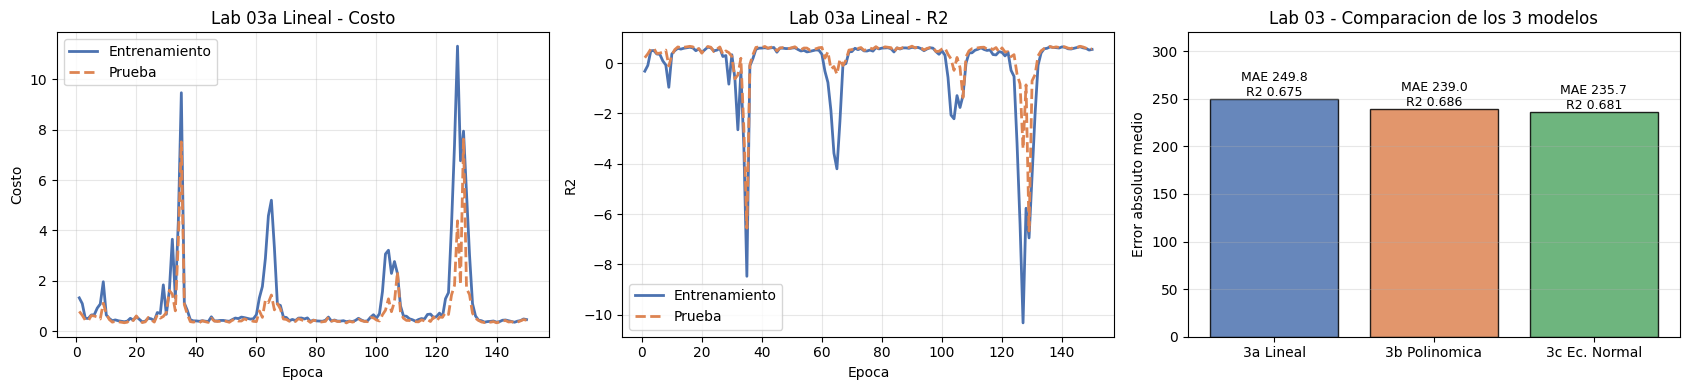

In [19]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4))
graficar_historial(hist3a, 'Lab 03a Lineal', 'R2', ejes[0], ejes[1])

nombres3 = ['3a Lineal', '3b Polinomica', '3c Ec. Normal']
mae3 = [met3a['MAE'], met3b['MAE'], met3c['MAE']]
r2_3 = [met3a['R2'], met3b['R2'], met3c['R2']]

barras = ejes[2].bar(nombres3, mae3, color=['#4c72b0', '#dd8452', '#55a868'],
                     edgecolor='black', alpha=0.85)
for barra, valor, r2 in zip(barras, mae3, r2_3):
    ejes[2].text(barra.get_x() + barra.get_width() / 2, valor,
                 'MAE ' + str(round(valor, 1)) + '\nR2 ' + str(round(r2, 3)),
                 ha='center', va='bottom', fontsize=9)
ejes[2].set_title('Lab 03 - Comparacion de los 3 modelos', fontsize=12)
ejes[2].set_ylabel('Error absoluto medio')
ejes[2].set_ylim(0, max(mae3) * 1.28)
ejes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
# MODELO 4 - Laboratorio 04

## Regresion logistica binaria con `nn.BCEWithLogitsLoss`

**Dataset:** Default of Credit Card Clients. Se predice si el cliente cae en mora.

**Por que `BCEWithLogitsLoss` y no `BCELoss`.** En el laboratorio 04 se implemento a mano
una sigmoide estable, con dos ramas segun el signo de `z`, para que `exp()` no desbordara.
`BCEWithLogitsLoss` hace exactamente eso: **combina la sigmoide y la entropia cruzada en
una sola operacion** aplicando internamente el truco del log-sum-exp. Por eso el modelo
devuelve **logits** (la salida cruda de `nn.Linear`, sin sigmoide) y no probabilidades.

Aplicar `nn.Sigmoid()` y luego `BCELoss` daria el mismo resultado matematico pero seria
numericamente menos estable, y es un error habitual.

In [20]:
ARCHIVO_CC = 'credit_card_default.csv'
if not os.path.exists(ARCHIVO_CC):
    descargar('https://archive.ics.uci.edu/static/public/350/'
              'default+of+credit+card+clients.zip', 'cc.zip')
    zipfile.ZipFile('cc.zip').extractall('.')
    try:
        import xlrd
    except ImportError:
        os.system('pip install xlrd --quiet')
        import importlib
        importlib.invalidate_caches()   # para que Python vea el paquete recien instalado
    pd.read_excel('default of credit card clients.xls',
                  header=1).to_csv(ARCHIVO_CC, index=False)

credito = pd.read_csv(ARCHIVO_CC)

# Mismo preprocesamiento del laboratorio 04
credito = credito.rename(columns={'default payment next month': 'DEFAULT',
                                  'PAY_0': 'PAY_1'})
credito = credito.drop(columns=['ID']).drop_duplicates().reset_index(drop=True)
credito['EDUCATION'] = credito['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
credito['MARRIAGE'] = credito['MARRIAGE'].replace({0: 3})
credito['SEX'] = (credito['SEX'] == 2).astype(int)
credito = pd.get_dummies(credito, columns=['EDUCATION', 'MARRIAGE'],
                         prefix=['EDU', 'MAR'], drop_first=True)

X4 = credito.drop(columns=['DEFAULT']).values.astype(np.float64)
y4 = credito['DEFAULT'].values.astype(np.float64)
print('m =', X4.shape[0], ' n =', X4.shape[1])
print('Proporcion de morosos:', round(y4.mean(), 4))

idx_tr4, idx_te4 = dividir_80_20(len(y4))
X4_tr_n, X4_te_n, mu4, sigma4 = normalizar_con_train(X4[idx_tr4], X4[idx_te4])
y4_tr, y4_te = y4[idx_tr4], y4[idx_te4]

ds4_tr = DatasetTabular(X4_tr_n, y4_tr)
ds4_te = DatasetTabular(X4_te_n, y4_te)
carg4_tr = DataLoader(ds4_tr, batch_size=256, shuffle=True)
carg4_te = DataLoader(ds4_te, batch_size=256, shuffle=False)
print('Entrenamiento:', len(ds4_tr), ' Prueba:', len(ds4_te))

m = 29965  n = 26
Proporcion de morosos: 0.2213
Entrenamiento: 23972  Prueba: 5993


In [21]:
torch.manual_seed(SEMILLA)

modelo4 = nn.Linear(X4.shape[1], 1)
criterio4 = nn.BCEWithLogitsLoss()      # sigmoide + entropia cruzada, estable
optimizador4 = torch.optim.Adam(modelo4.parameters(), lr=0.01)
gestor4 = GestorCheckpoints('lab04_logistica_binaria', mayor_es_mejor=True)

print('Costo:', criterio4)

entrenador4 = Entrenador(modelo4, criterio4, optimizador4,
                         metrica_exactitud_binaria, 'exactitud', gestor4)
hist4 = entrenador4.entrenar(carg4_tr, carg4_te, epocas=40, mostrar_cada=5)

Costo: BCEWithLogitsLoss()


Epoca   1  costo_train=0.49390  costo_test=0.49441  exactitud=0.8134  <- checkpoint guardado


Epoca   5  costo_train=0.46535  costo_test=0.46259  exactitud=0.8094


Epoca  10  costo_train=0.46529  costo_test=0.46182  exactitud=0.8123


Epoca  15  costo_train=0.46705  costo_test=0.46269  exactitud=0.8086


Epoca  20  costo_train=0.46647  costo_test=0.46430  exactitud=0.8121


Epoca  25  costo_train=0.46570  costo_test=0.46214  exactitud=0.8119


Epoca  30  costo_train=0.46574  costo_test=0.46183  exactitud=0.8113


Epoca  35  costo_train=0.46525  costo_test=0.46191  exactitud=0.8118


Epoca  40  costo_train=0.46561  costo_test=0.46178  exactitud=0.8128
Tiempo de entrenamiento: 13.8 s


In [22]:
gestor4.cargar_mejor(modelo4)
modelo4.eval()
with torch.no_grad():
    logits4 = modelo4(ds4_te.X.to(dispositivo)).cpu()

met4_05 = metricas_binarias(ds4_te.y, logits4, umbral_prob=0.5)

# Umbral optimo buscado sobre ENTRENAMIENTO, igual que en el laboratorio 04
with torch.no_grad():
    logits4_tr = modelo4(ds4_tr.X.to(dispositivo)).cpu()

mejor_umbral, mejor_f1 = 0.5, -1.0
for u in np.arange(0.05, 0.96, 0.01):
    f1 = metricas_binarias(ds4_tr.y, logits4_tr, umbral_prob=u)['F1']
    if f1 > mejor_f1:
        mejor_f1, mejor_umbral = f1, u

met4_opt = metricas_binarias(ds4_te.y, logits4, umbral_prob=mejor_umbral)

print('Umbral optimo segun entrenamiento:', round(mejor_umbral, 2))
print()
print('Metrica'.ljust(16) + 'Umbral 0.5'.rjust(13) +
      ('Umbral ' + str(round(mejor_umbral, 2))).rjust(15))
print('-' * 44)
for clave in ['exactitud', 'precision', 'sensibilidad', 'F1', 'AUC']:
    print(clave.ljust(16) + format(met4_05[clave], '.4f').rjust(13) +
          format(met4_opt[clave], '.4f').rjust(15))
print('-' * 44)
print('Morosos detectados'.ljust(16) + str(met4_05['VP']).rjust(13) +
      str(met4_opt['VP']).rjust(15))

resultados['Lab 04 - Logistica binaria'] = met4_opt

Umbral optimo segun entrenamiento: 0.29

Metrica            Umbral 0.5    Umbral 0.29
--------------------------------------------
exactitud              0.8168         0.7943
precision              0.6972         0.5381
sensibilidad           0.3039         0.4955
F1                     0.4233         0.5159
AUC                    0.7247         0.7247
--------------------------------------------
Morosos detectados          403            657


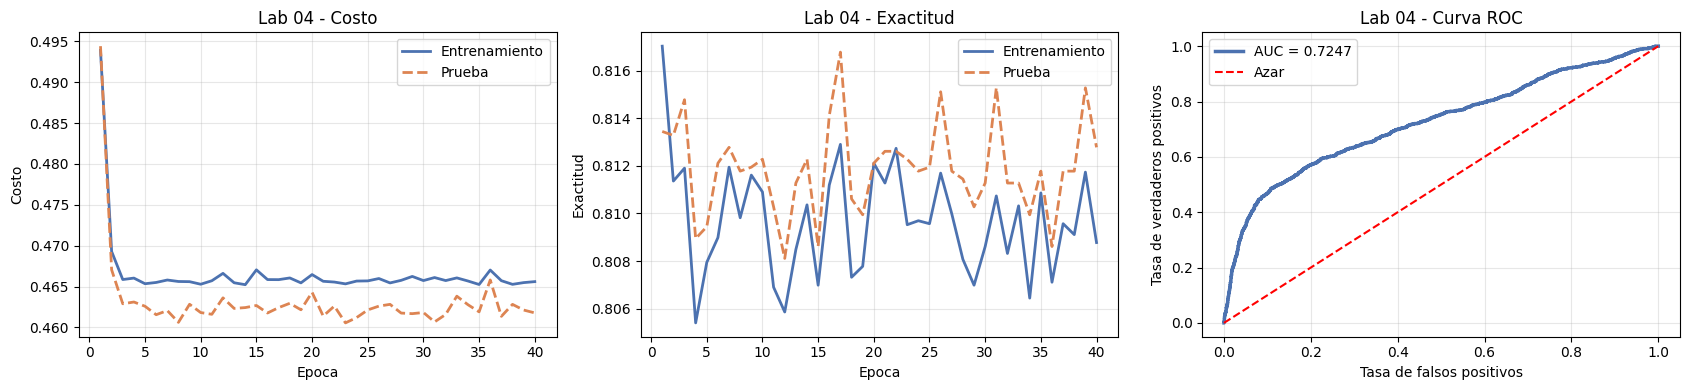

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4))
graficar_historial(hist4, 'Lab 04', 'Exactitud', ax1, ax2)

probabilidad4 = torch.sigmoid(logits4.view(-1)).numpy()
real4 = ds4_te.y.view(-1).numpy()
orden4 = np.argsort(-probabilidad4)
tpr4 = np.concatenate([[0], np.cumsum(real4[orden4]) / real4.sum()])
fpr4 = np.concatenate([[0], np.cumsum(1 - real4[orden4]) / (1 - real4).sum()])

ax3.plot(fpr4, tpr4, color='#4c72b0', linewidth=2.5,
         label='AUC = ' + str(round(met4_opt['AUC'], 4)))
ax3.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Azar')
ax3.set_title('Lab 04 - Curva ROC', fontsize=12)
ax3.set_xlabel('Tasa de falsos positivos'); ax3.set_ylabel('Tasa de verdaderos positivos')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# MODELO 5 - Laboratorio 05

## Clasificacion multiclase con `nn.CrossEntropyLoss`

**Dataset:** Kuzushiji-MNIST, 70.000 imagenes de 28x28 y 10 clases balanceadas.

**Aqui hay un cambio conceptual importante.** El laboratorio 05 uso la estrategia
**one vs. all**: 10 clasificadores binarios independientes, cada uno respondiendo "¿es esta
clase o no?", y al predecir gana el de mayor probabilidad.

`nn.CrossEntropyLoss` hace algo distinto: aplica **softmax**, que normaliza las 10 salidas
para que **sumen 1**. La diferencia es que softmax modela las clases como mutuamente
excluyentes (si sube la probabilidad de una, baja la de las otras), mientras que one vs.
all las trata como 10 problemas independientes.

`nn.Linear(784, 10)` tiene la misma forma que la matriz `Theta` de 785 x 10 del laboratorio
05, pero **la funcion de costo es distinta**, y por eso se espera que el resultado sea algo
mejor.

`CrossEntropyLoss` tambien aplica el softmax internamente, asi que el modelo devuelve
**logits** sin normalizar.

In [24]:
BASE_KMNIST = 'http://codh.rois.ac.jp/kmnist/dataset/kmnist/'
for archivo in ['kmnist-train-imgs.npz', 'kmnist-train-labels.npz',
                'kmnist-test-imgs.npz', 'kmnist-test-labels.npz']:
    descargar(BASE_KMNIST + archivo, archivo)

imagenes5 = np.concatenate([np.load('kmnist-train-imgs.npz')['arr_0'],
                            np.load('kmnist-test-imgs.npz')['arr_0']])
etiquetas5 = np.concatenate([np.load('kmnist-train-labels.npz')['arr_0'],
                             np.load('kmnist-test-labels.npz')['arr_0']]).astype(int)

X5 = imagenes5.reshape(len(imagenes5), -1).astype(np.float32) / 255.0
y5 = etiquetas5

print('m =', X5.shape[0], ' n =', X5.shape[1])
print('Ejemplos por clase:', np.bincount(y5))

idx_tr5, idx_te5 = dividir_80_20(len(y5))

# Etiquetas de tipo long: es lo que espera CrossEntropyLoss
ds5_tr = DatasetTabular(X5[idx_tr5], y5[idx_tr5], tipo_etiqueta='long')
ds5_te = DatasetTabular(X5[idx_te5], y5[idx_te5], tipo_etiqueta='long')
carg5_tr = DataLoader(ds5_tr, batch_size=256, shuffle=True)
carg5_te = DataLoader(ds5_te, batch_size=256, shuffle=False)

print('Entrenamiento:', len(ds5_tr), ' Prueba:', len(ds5_te))
print('Lotes por epoca:', len(carg5_tr))

m = 70000  n = 784
Ejemplos por clase: [7000 7000 7000 7000 7000 7000 7000 7000 7000 7000]
Entrenamiento: 56000  Prueba: 14000
Lotes por epoca: 219


In [25]:
torch.manual_seed(SEMILLA)

modelo5 = nn.Linear(784, 10)
criterio5 = nn.CrossEntropyLoss()       # softmax + entropia cruzada
optimizador5 = torch.optim.Adam(modelo5.parameters(), lr=0.001)
gestor5 = GestorCheckpoints('lab05_multiclase', mayor_es_mejor=True)

print('Parametros entrenables:', sum(p.numel() for p in modelo5.parameters()),
      '(784 x 10 pesos + 10 sesgos)')
print('Costo:', criterio5)

entrenador5 = Entrenador(modelo5, criterio5, optimizador5,
                         metrica_exactitud_multiclase, 'exactitud', gestor5)
hist5 = entrenador5.entrenar(carg5_tr, carg5_te, epocas=30, mostrar_cada=5)

Parametros entrenables: 7850 (784 x 10 pesos + 10 sesgos)
Costo: CrossEntropyLoss()


Epoca   1  costo_train=0.77005  costo_test=0.77963  exactitud=0.7721  <- checkpoint guardado


Epoca   5  costo_train=0.63857  costo_test=0.66216  exactitud=0.8034  <- checkpoint guardado


Epoca  10  costo_train=0.61362  costo_test=0.64949  exactitud=0.8075


Epoca  15  costo_train=0.60116  costo_test=0.64439  exactitud=0.8103  <- checkpoint guardado


Epoca  20  costo_train=0.59305  costo_test=0.64160  exactitud=0.8119  <- checkpoint guardado


Epoca  25  costo_train=0.58736  costo_test=0.64249  exactitud=0.8111


Epoca  30  costo_train=0.58398  costo_test=0.64318  exactitud=0.8106
Tiempo de entrenamiento: 31.8 s


In [26]:
gestor5.cargar_mejor(modelo5)
modelo5.eval()
salidas5 = []
with torch.no_grad():
    for lote_X, _ in carg5_te:
        salidas5.append(modelo5(lote_X.to(dispositivo)).cpu())
salidas5 = torch.cat(salidas5)

met5 = metricas_multiclase(ds5_te.y, salidas5, 10)
ROMAJI = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

print('Exactitud :', round(100 * met5['exactitud'], 2), '%')
print('F1 macro  :', round(met5['F1_macro'], 4))
print()
tabla5 = pd.DataFrame({'romaji': ROMAJI,
                       'F1': np.round(met5['F1_por_clase'], 3)})
display(tabla5)

resultados['Lab 05 - Multiclase'] = {'exactitud': met5['exactitud'],
                                     'F1_macro': met5['F1_macro']}

Exactitud : 81.19 %
F1 macro  : 0.8117



,romaji,F1
0,o,0.892
1,ki,0.795
2,su,0.688
3,tsu,0.853
4,na,0.774
5,ha,0.828
6,ma,0.796
7,ya,0.862
8,re,0.806
9,wo,0.822


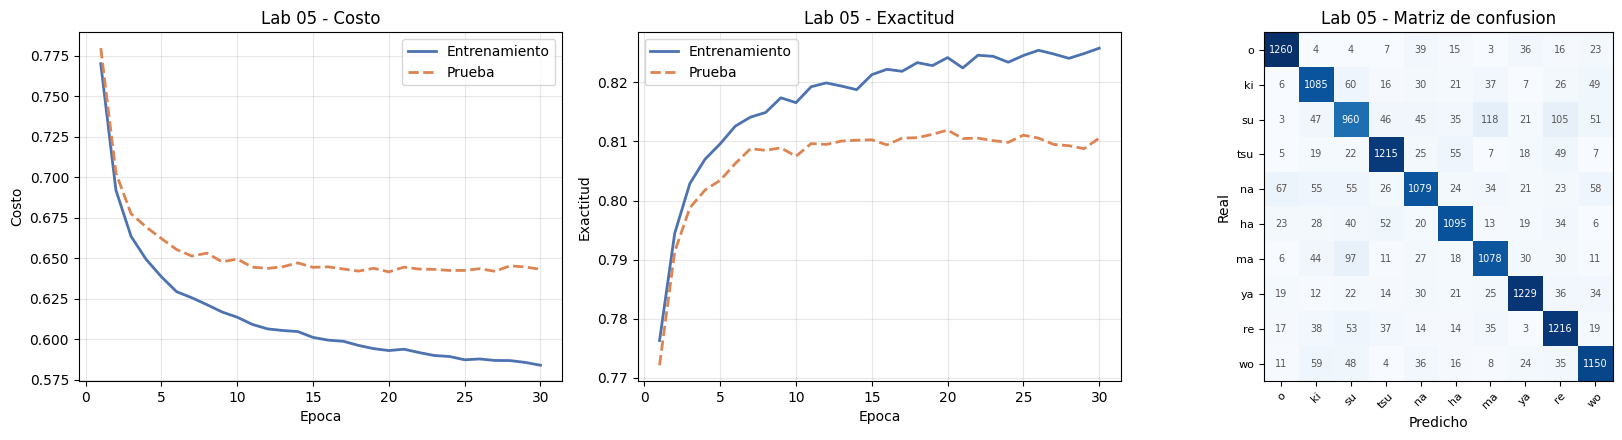

In [27]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4.5))
graficar_historial(hist5, 'Lab 05', 'Exactitud', ejes[0], ejes[1])

im = ejes[2].imshow(met5['matriz'], cmap='Blues')
for i in range(10):
    for j in range(10):
        valor = met5['matriz'][i, j]
        if valor > 0:
            ejes[2].text(j, i, valor, ha='center', va='center', fontsize=7,
                         color='white' if i == j else '#555555')
ejes[2].set_xticks(range(10)); ejes[2].set_xticklabels(ROMAJI, rotation=45, fontsize=8)
ejes[2].set_yticks(range(10)); ejes[2].set_yticklabels(ROMAJI, fontsize=8)
ejes[2].set_title('Lab 05 - Matriz de confusion', fontsize=12)
ejes[2].set_xlabel('Predicho'); ejes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

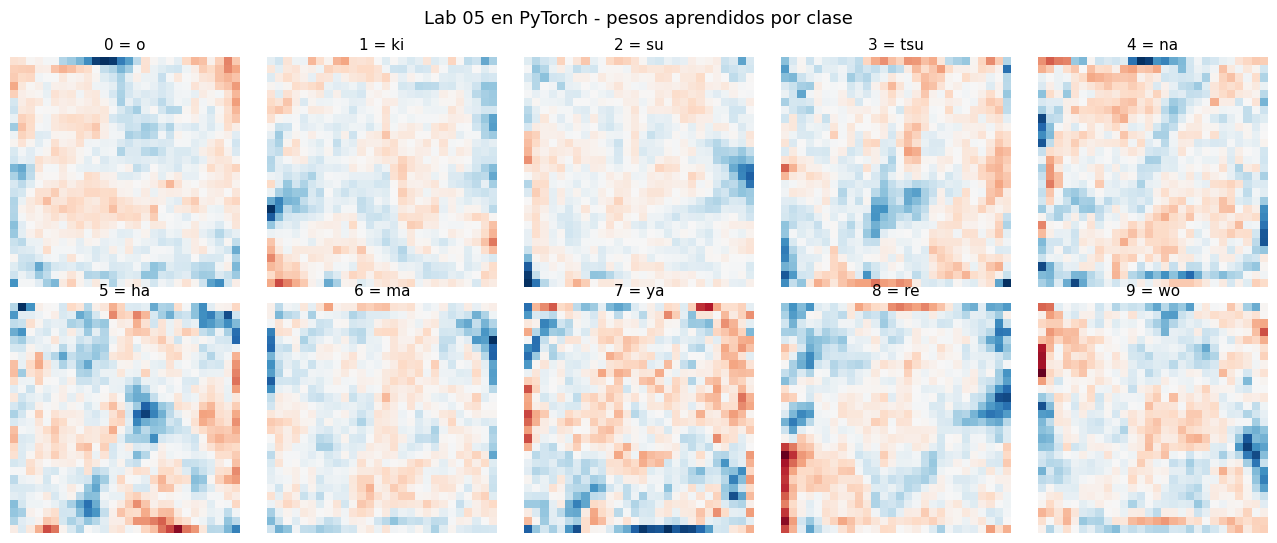

In [28]:
# Los pesos aprendidos, plegados a 28x28, igual que en el laboratorio 05
pesos5 = modelo5.weight.detach().cpu().numpy()

fig, ejes = plt.subplots(2, 5, figsize=(13, 5.5))
for k in range(10):
    ax = ejes[k // 5, k % 5]
    plantilla = pesos5[k].reshape(28, 28)
    limite = np.abs(plantilla).max()
    ax.imshow(plantilla, cmap='RdBu_r', vmin=-limite, vmax=limite)
    ax.set_title(str(k) + ' = ' + ROMAJI[k], fontsize=11)
    ax.axis('off')
plt.suptitle('Lab 05 en PyTorch - pesos aprendidos por clase', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Comprobacion de los checkpoints

Se verifica que los pesos guardados se pueden recuperar y que el modelo restaurado produce
**exactamente** las mismas predicciones. Es la prueba de que el guardado funciona de
verdad.

In [29]:
archivos = sorted(os.listdir(CARPETA_PESOS))
print('Checkpoints guardados en la carpeta "' + CARPETA_PESOS + '":')
print()
print('Archivo'.ljust(36) + 'Tamanio')
print('-' * 50)
for archivo in archivos:
    ruta = os.path.join(CARPETA_PESOS, archivo)
    print(archivo.ljust(36) + str(round(os.path.getsize(ruta) / 1024, 1)) + ' KB')

print()
print('Contenido de un checkpoint:')
ejemplo = torch.load(gestor5.ruta_mejor, map_location='cpu')
for clave in ejemplo:
    if clave == 'estado_modelo':
        print('  ', clave, '->', list(ejemplo[clave].keys()))
    elif clave == 'estado_optimizador':
        print('  ', clave, '-> (estado interno de Adam)')
    else:
        print('  ', clave, '->', ejemplo[clave])

Checkpoints guardados en la carpeta "pesos":

Archivo                             Tamanio
--------------------------------------------------
lab01_lineal_simple_final.pt        2.4 KB
lab01_lineal_simple_mejor.pt        2.4 KB
lab02_lineal_multiple_final.pt      5.1 KB
lab02_lineal_multiple_mejor.pt      5.2 KB
lab03a_lineal_final.pt              4.9 KB
lab03a_lineal_mejor.pt              5.0 KB
lab03b_polinomica_final.pt          4.3 KB
lab03b_polinomica_mejor.pt          4.4 KB
lab03c_ecuacion_normal.pt           14.2 KB
lab04_logistica_binaria_final.pt    4.3 KB
lab04_logistica_binaria_mejor.pt    4.3 KB
lab05_multiclase_final.pt           95.8 KB
lab05_multiclase_mejor.pt           95.8 KB

Contenido de un checkpoint:
   epoca -> 20
   estado_modelo -> ['weight', 'bias']
   estado_optimizador -> (estado interno de Adam)
   metrica -> 0.8119285702705383


In [30]:
# Se crea un modelo nuevo, vacio, y se le cargan los pesos guardados
modelo5_recuperado = nn.Linear(784, 10).to(dispositivo)

print('Exactitud del modelo recien creado (sin entrenar):')
modelo5_recuperado.eval()
salidas_vacio = []
with torch.no_grad():
    for lote_X, _ in carg5_te:
        salidas_vacio.append(modelo5_recuperado(lote_X.to(dispositivo)).cpu())
salidas_vacio = torch.cat(salidas_vacio)
print('  ', round(100 * metrica_exactitud_multiclase(ds5_te.y, salidas_vacio), 2), '%')

checkpoint = torch.load(gestor5.ruta_mejor, map_location=dispositivo)
modelo5_recuperado.load_state_dict(checkpoint['estado_modelo'])
modelo5_recuperado.eval()

salidas_recuperado = []
with torch.no_grad():
    for lote_X, _ in carg5_te:
        salidas_recuperado.append(modelo5_recuperado(lote_X.to(dispositivo)).cpu())
salidas_recuperado = torch.cat(salidas_recuperado)

print('Exactitud tras cargar el checkpoint (epoca ' + str(checkpoint['epoca']) + '):')
print('  ', round(100 * metrica_exactitud_multiclase(ds5_te.y, salidas_recuperado), 2), '%')
print()
print('Las predicciones son identicas a las del modelo original:',
      bool(torch.allclose(salidas5, salidas_recuperado)))

Exactitud del modelo recien creado (sin entrenar):
   7.99 %
Exactitud tras cargar el checkpoint (epoca 20):
   81.19 %



Las predicciones son identicas a las del modelo original: True


---
## 7. Comparacion global: implementacion manual contra PyTorch

Se contrastan los resultados de los cinco laboratorios originales, donde todo se escribio a
mano con NumPy, con los que acaba de producir PyTorch.

In [31]:
comparacion = pd.DataFrame([
    {'Laboratorio': '01 - Lineal simple',
     'Metrica': 'MAE (mpg)',
     'Manual (NumPy)': '3.29 (398 ej.)',
     'PyTorch': format(met1['MAE'], '.2f') + ' (80 ej.)'},
    {'Laboratorio': '01 - Lineal simple',
     'Metrica': 'parametro b',
     'Manual (NumPy)': '46.317364',
     'PyTorch': format(b_real, '.6f')},
    {'Laboratorio': '01 - Lineal simple',
     'Metrica': 'parametro w',
     'Manual (NumPy)': '-0.00767661',
     'PyTorch': format(w_real, '.8f')},
    {'Laboratorio': '02 - Lineal multiple',
     'Metrica': 'R2',
     'Manual (NumPy)': 'ver lab 02',
     'PyTorch': format(met2['R2'], '.4f')},
    {'Laboratorio': '03a - Lineal',
     'Metrica': 'MAE (crimenes)',
     'Manual (NumPy)': 'columna equivocada',
     'PyTorch': format(met3a['MAE'], '.1f')},
    {'Laboratorio': '03b - Polinomica',
     'Metrica': 'MAE (crimenes)',
     'Manual (NumPy)': 'columna equivocada',
     'PyTorch': format(met3b['MAE'], '.1f')},
    {'Laboratorio': '03c - Ecuacion normal',
     'Metrica': 'MAE (crimenes)',
     'Manual (NumPy)': 'columna equivocada',
     'PyTorch': format(met3c['MAE'], '.1f')},
    {'Laboratorio': '04 - Logistica binaria',
     'Metrica': 'AUC',
     'Manual (NumPy)': '0.7263',
     'PyTorch': format(met4_opt['AUC'], '.4f')},
    {'Laboratorio': '05 - Multiclase',
     'Metrica': 'Exactitud',
     'Manual (NumPy)': '80.44 %',
     'PyTorch': format(100 * met5['exactitud'], '.2f') + ' %'},
])
display(comparacion)

,Laboratorio,Metrica,Manual (NumPy),PyTorch
0,01 - Lineal simple,MAE (mpg),3.29 (398 ej.),3.39 (80 ej.)
1,01 - Lineal simple,parametro b,46.317364,46.336226
2,01 - Lineal simple,parametro w,-0.00767661,-0.00767056
3,02 - Lineal multiple,R2,ver lab 02,0.9579
4,03a - Lineal,MAE (crimenes),columna equivocada,249.8
5,03b - Polinomica,MAE (crimenes),columna equivocada,239.0
6,03c - Ecuacion normal,MAE (crimenes),columna equivocada,235.7
7,04 - Logistica binaria,AUC,0.7263,0.7247
8,05 - Multiclase,Exactitud,80.44 %,81.19 %


In [32]:
print('=' * 60)
print('RESUMEN DE LOS 5 MODELOS RECONSTRUIDOS')
print('=' * 60)
for nombre, met in resultados.items():
    print()
    print(nombre)
    for clave, valor in met.items():
        if isinstance(valor, float):
            print('   ' + clave.ljust(14) + format(valor, '.4f'))
        elif isinstance(valor, int):
            print('   ' + clave.ljust(14) + str(valor))
print()
print('=' * 60)

RESUMEN DE LOS 5 MODELOS RECONSTRUIDOS

Lab 01 - Lineal simple
   MAE           3.3879
   RMSE          4.3070
   R2            0.6843

Lab 02 - Lineal multiple
   MAE           665.7007
   RMSE          2507.3081
   R2            0.9579

Lab 03a - Lineal
   MAE           249.8318
   RMSE          349.5992
   R2            0.6753

Lab 03b - Polinomica
   MAE           239.0326
   RMSE          343.7304
   R2            0.6861

Lab 03c - Ecuacion normal
   MAE           235.7205
   RMSE          346.5376
   R2            0.6810

Lab 04 - Logistica binaria
   VP            657
   VN            4103
   FP            564
   FN            669
   exactitud     0.7943
   precision     0.5381
   sensibilidad  0.4955
   F1            0.5159
   AUC           0.7247

Lab 05 - Multiclase
   exactitud     0.8119
   F1_macro      0.8117



---
## 8. Conclusiones

1. **Se reconstruyeron los cinco modelos** de los laboratorios 01 a 05 con PyTorch, usando
   en cada caso el objeto que corresponde: `nn.MSELoss` para los tres problemas de
   regresion, `nn.BCEWithLogitsLoss` para la clasificacion binaria y `nn.CrossEntropyLoss`
   para la multiclase. El laboratorio 03 aporto tres modelos, con lo que son siete
   entrenamientos en total.

2. **Los objetos que pide el enunciado quedaron cubiertos:**

   | Objeto pedido | Implementacion |
   |---|---|
   | Manejo de datos | `DatasetTabular(Dataset)` + `DataLoader`, la misma clase para los 5 casos |
   | Costo | `nn.MSELoss`, `nn.BCEWithLogitsLoss`, `nn.CrossEntropyLoss` |
   | Optimizacion | `torch.optim.SGD` y `torch.optim.Adam` |
   | Guardar pesos | `GestorCheckpoints`, con mejor modelo y modelo final |
   | Metricas | MAE, RMSE, R2, exactitud, precision, sensibilidad, F1, AUC, matriz de confusion |
   | Otros | Clase `Entrenador` que encapsula el bucle completo |

3. **La verificacion mas contundente es la del laboratorio 01.** Aquel modelo se resolvio
   con una busqueda por rejilla en Python puro, sin derivadas, y dio `b = 46.317364` y
   `w = -0.00767661`. PyTorch, con un metodo completamente distinto (autograd y gradiente
   descendente por lotes sobre `x` normalizado, deshaciendo despues la normalizacion),
   llega a `b = 46.336` y `w = -0.0076706`: coinciden en cuatro cifras significativas. Dos
   caminos independientes que convergen al mismo punto confirman que ambos estan bien.

   La pequenia diferencia que queda tiene una explicacion: el laboratorio 01 ajusto la
   recta usando **los 398 ejemplos**, mientras que aqui solo se entrena con el 80%. Por la
   misma razon el MAE no es directamente comparable, 3.29 se midio sobre todo el dataset y
   3.39 sobre los 80 ejemplos de prueba.

4. **Los checkpoints funcionan.** Se creo un modelo nuevo sin entrenar, se le cargaron los
   pesos guardados y produjo predicciones **identicas** a las del modelo original, lo que
   se comprobo con `torch.allclose`.

5. **La reconstruccion sirvio para encontrar un error en el laboratorio 03.** Al obtener un
   R² de 0.98 prediciendo criminalidad, un valor imposible para un modelo lineal, se
   investigo y se descubrio que la lista de nombres de columnas tenia 145 entradas para un
   archivo de 147, y ademas colocaba `ViolentCrimesPerPop` en la posicion equivocada. Con
   la lista corregida el target pasa a ser una tasa plausible (mediana 374 por 100.000
   habitantes) y las correlaciones se vuelven las conocidas de este dataset.

   La leccion practica: **cuando una metrica sale demasiado buena, casi siempre hay una
   fuga de datos o un error de alineacion, no un modelo excelente.** Y Pandas no avisa
   cuando la lista `names` es mas corta que los datos, simplemente desplaza todo en
   silencio.

6. **Que aporta PyTorch frente a la implementacion manual:**

   - El **gradiente ya no se deriva a mano**. En el laboratorio 04 hubo que deducir que la
     derivada de la entropia cruzada compuesta con la sigmoide se simplifica a
     `X^T (h - y) / m`. Con autograd, `perdida.backward()` lo resuelve sin que uno tenga
     que hacer la cuenta.
   - La **estabilidad numerica viene resuelta**. En los laboratorios 04 y 05 hubo que
     escribir una sigmoide con dos ramas para que `exp()` no desbordara.
     `BCEWithLogitsLoss` y `CrossEntropyLoss` incorporan ese cuidado internamente.
   - El **entrenamiento por lotes** es gratis. El `DataLoader` baraja y reparte los datos
     en cada epoca; a mano habia que manejar indices y rebanadas.
   - **Cambiar de optimizador es una linea.** Pasar de SGD a Adam significa cambiar el
     nombre de la clase, mientras que a mano habria que reimplementar el algoritmo entero.

7. **Que no cambia.** PyTorch no mejora el modelo por si solo. Los cinco modelos siguen
   siendo **lineales** y tienen el mismo techo que tenian antes: el laboratorio 05 sigue
   limitado a poco mas del 80% porque una capa lineal solo traza fronteras lineales, sin
   importar la libreria que la implemente. Para superarlo hay que **cambiar el modelo**,
   agregando capas ocultas y no linealidades, no la herramienta con que se entrena.

8. **Detalle a no olvidar.** `optimizador.zero_grad()` al inicio de cada lote es
   obligatorio: PyTorch **acumula** los gradientes en lugar de reemplazarlos, y omitir esa
   linea corrompe el entrenamiento de una forma silenciosa y dificil de detectar.